<a href="https://colab.research.google.com/github/e23323-dot/Statistical-Learning-e23323/blob/main/Assignment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

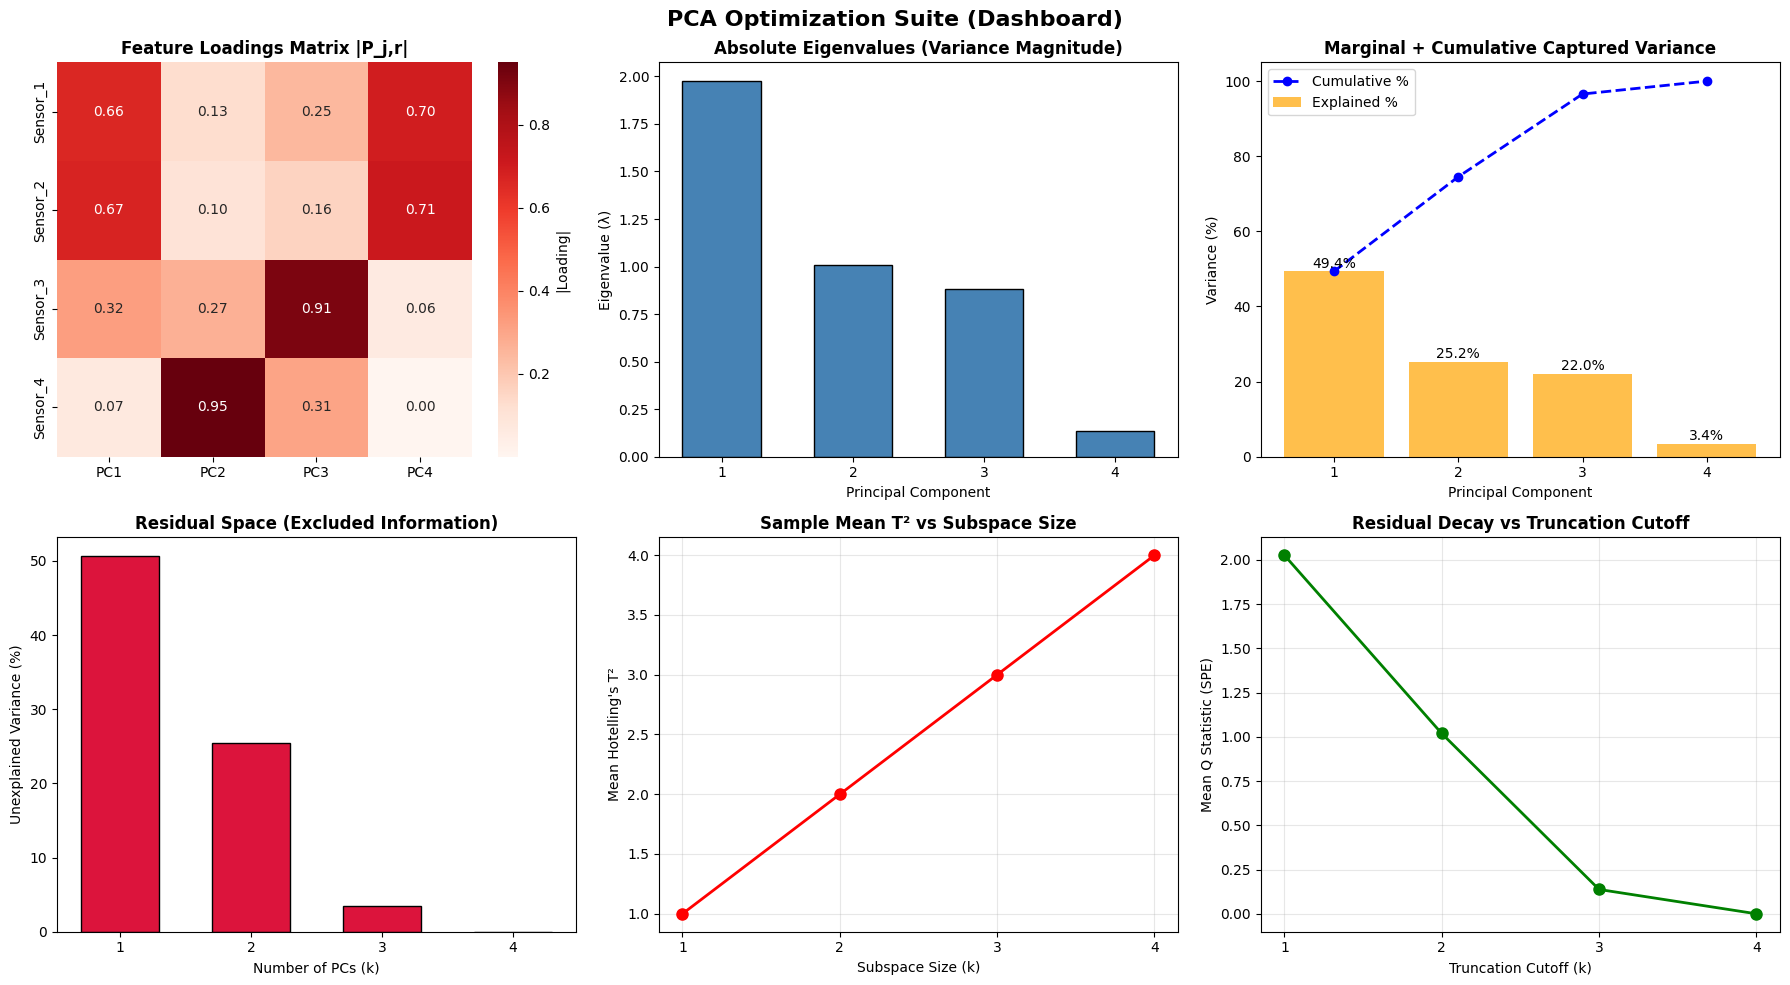

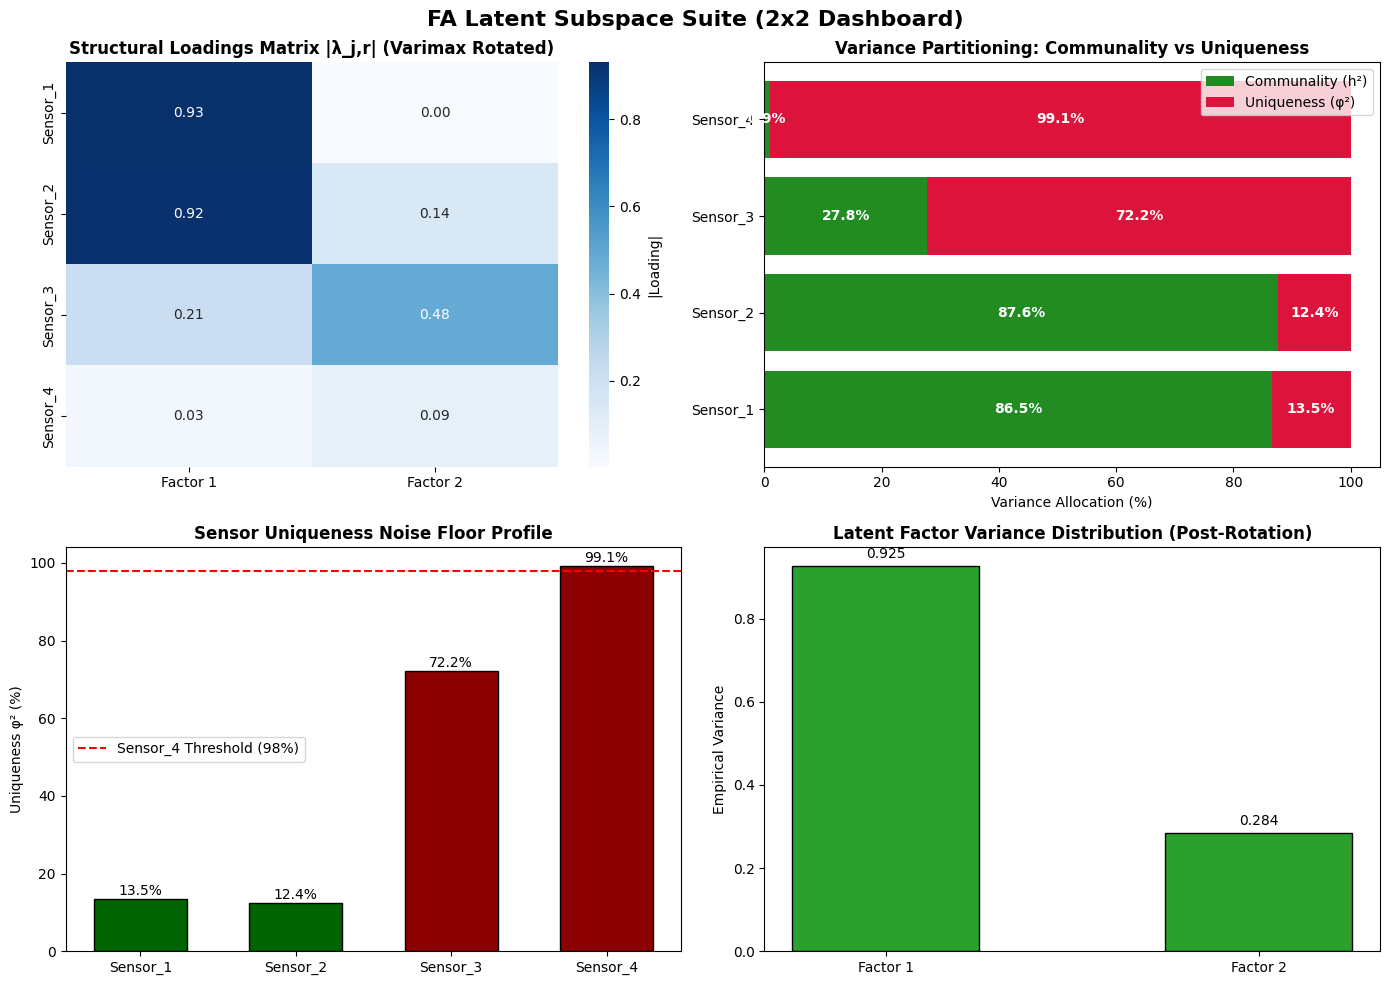

Sensor_4 Uniqueness (φ²): 99.13%
QUESTION 1: The Total Variance Illusion

1. A uniqueness value close to 100% tells us that Sensor_4 is dominated by 
   localized noise rather than shared structural signals. Almost all of its 
   variance is specific to itself, with almost no communality with other sensors.

2. PCA maximizes total variance without caring whether variance comes from 
   real structure or pure noise. Sensor_4 has massive noise variance (~2.0) 
   compared to other sensors (~0.3-0.5). PCA's first components align with 
   this high-variance direction, so the eigenvalues get artificially inflated 
   by sensor noise rather than true physical processes.

3. If an engineer relies only on PCA, they might keep too many components 
   thinking they represent real structure when they actually model sensor noise. 
   This causes false alarms from sensor fluctuations and missed detection of 
   real structural anomalies.

QUESTION 2: Decoupling Structural Loading via Rotation

1. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
import seaborn as sns

np.random.seed(42)
n_samples = 2500

f1 = np.random.normal(0, 1, n_samples)
f2 = np.random.normal(0, 1, n_samples)

s1 = 0.85 * f1 + 0.10 * f2 + np.random.normal(0, 0.3, n_samples)
s2 = 0.80 * f1 + 0.15 * f2 + np.random.normal(0, 0.35, n_samples)
s3 = 0.12 * f1 + 0.90 * f2 + np.random.normal(0, 0.25, n_samples)
s4 = 0.02 * f1 + 0.05 * f2 + np.random.normal(0, 1.40, n_samples)

df_asset = pd.DataFrame(
    data=np.vstack([s1, s2, s3, s4]).T,
    columns=['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_asset)

pca_full = PCA()
pca_full.fit(data_scaled)
scores_pca = pca_full.transform(data_scaled)
loadings_pca = pca_full.components_.T
eigenvalues = pca_full.explained_variance_
explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)
unexplained_var = 100 - cumulative_var * 100

k_max = 4
t2_mean = []
q_mean = []

for k in range(1, k_max + 1):
    pca_k = PCA(n_components=k)
    scores_k = pca_k.fit_transform(data_scaled)
    lambda_inv = 1.0 / pca_k.explained_variance_
    t2_vals = np.sum((scores_k ** 2) * lambda_inv, axis=1)
    t2_mean.append(np.mean(t2_vals))
    reconstructed = pca_k.inverse_transform(scores_k)
    residuals = data_scaled - reconstructed
    q_vals = np.sum(residuals ** 2, axis=1)
    q_mean.append(np.mean(q_vals))

fig_pca = plt.figure(figsize=(18, 10))

ax1 = plt.subplot(2, 3, 1)
sns.heatmap(np.abs(loadings_pca), annot=True, fmt='.2f', cmap='Reds',
            xticklabels=[f'PC{i+1}' for i in range(4)],
            yticklabels=df_asset.columns, ax=ax1, cbar_kws={'label': '|Loading|'})
ax1.set_title('Feature Loadings Matrix |P_j,r|', fontweight='bold')

ax2 = plt.subplot(2, 3, 2)
ax2.bar(range(1, 5), eigenvalues, color='steelblue', edgecolor='black', width=0.6)
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Eigenvalue (λ)')
ax2.set_title('Absolute Eigenvalues (Variance Magnitude)', fontweight='bold')
ax2.set_xticks(range(1, 5))

ax3 = plt.subplot(2, 3, 3)
bars = ax3.bar(range(1, 5), explained_var_ratio * 100, color='orange', alpha=0.7, label='Explained %')
ax3.plot(range(1, 5), cumulative_var * 100, 'b--o', linewidth=2, label='Cumulative %')
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Variance (%)')
ax3.set_title('Marginal + Cumulative Captured Variance', fontweight='bold')
ax3.legend()
ax3.set_xticks(range(1, 5))
for bar, val in zip(bars, explained_var_ratio * 100):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')

ax4 = plt.subplot(2, 3, 4)
ax4.bar(range(1, 5), unexplained_var, color='crimson', edgecolor='black', width=0.6)
ax4.set_xlabel('Number of PCs (k)')
ax4.set_ylabel('Unexplained Variance (%)')
ax4.set_title('Residual Space (Excluded Information)', fontweight='bold')
ax4.set_xticks(range(1, 5))

ax5 = plt.subplot(2, 3, 5)
ax5.plot(range(1, k_max + 1), t2_mean, 'ro-', linewidth=2, markersize=8)
ax5.set_xlabel('Subspace Size (k)')
ax5.set_ylabel('Mean Hotelling\'s T²')
ax5.set_title('Sample Mean T² vs Subspace Size', fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_xticks(range(1, 5))

ax6 = plt.subplot(2, 3, 6)
ax6.plot(range(1, k_max + 1), q_mean, 'go-', linewidth=2, markersize=8)
ax6.set_xlabel('Truncation Cutoff (k)')
ax6.set_ylabel('Mean Q Statistic (SPE)')
ax6.set_title('Residual Decay vs Truncation Cutoff', fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_xticks(range(1, 5))

plt.suptitle('PCA Optimization Suite (Dashboard)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

fa = FactorAnalysis(n_components=2, rotation='varimax', random_state=42)
fa_scores = fa.fit_transform(data_scaled)
loadings_fa = fa.components_.T
communalities = np.sum(loadings_fa ** 2, axis=1)
uniqueness = 1 - communalities
factor_var = np.var(fa_scores, axis=0)

fig_fa = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
sns.heatmap(np.abs(loadings_fa), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Factor 1', 'Factor 2'],
            yticklabels=df_asset.columns, ax=ax1, cbar_kws={'label': '|Loading|'})
ax1.set_title('Structural Loadings Matrix |λ_j,r| (Varimax Rotated)', fontweight='bold')

ax2 = plt.subplot(2, 2, 2)
sensors = df_asset.columns
x_pos = np.arange(len(sensors))
ax2.barh(x_pos, communalities * 100, left=0, color='forestgreen', label='Communality (h²)')
ax2.barh(x_pos, uniqueness * 100, left=communalities * 100, color='crimson', label='Uniqueness (φ²)')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(sensors)
ax2.set_xlabel('Variance Allocation (%)')
ax2.set_title('Variance Partitioning: Communality vs Uniqueness', fontweight='bold')
ax2.legend()
for i, (comm, uniq) in enumerate(zip(communalities * 100, uniqueness * 100)):
    ax2.text(comm/2, i, f'{comm:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax2.text(comm + uniq/2, i, f'{uniq:.1f}%', ha='center', va='center', color='white', fontweight='bold')

ax3 = plt.subplot(2, 2, 3)
colors = ['darkgreen' if u < 0.5 else 'darkred' for u in uniqueness]
ax3.bar(sensors, uniqueness * 100, color=colors, edgecolor='black', width=0.6)
ax3.axhline(y=98, color='red', linestyle='--', linewidth=1.5, label='Sensor_4 Threshold (98%)')
ax3.set_ylabel('Uniqueness φ² (%)')
ax3.set_title('Sensor Uniqueness Noise Floor Profile', fontweight='bold')
ax3.legend()
for i, (sens, val) in enumerate(zip(sensors, uniqueness * 100)):
    ax3.text(i, val + 1, f'{val:.1f}%', ha='center')

ax4 = plt.subplot(2, 2, 4)
ax4.bar(['Factor 1', 'Factor 2'], factor_var, color='#2ca02c', edgecolor='black', width=0.5)
ax4.set_ylabel('Empirical Variance')
ax4.set_title('Latent Factor Variance Distribution (Post-Rotation)', fontweight='bold')
for i, val in enumerate(factor_var):
    ax4.text(i, val + 0.02, f'{val:.3f}', ha='center')

plt.suptitle('FA Latent Subspace Suite (2x2 Dashboard)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


print(f"Sensor_4 Uniqueness (φ²): {uniqueness[3]*100:.2f}%")


print("QUESTION 1: The Total Variance Illusion")
print("""
1. A uniqueness value close to 100% tells us that Sensor_4 is dominated by
   localized noise rather than shared structural signals. Almost all of its
   variance is specific to itself, with almost no communality with other sensors.

2. PCA maximizes total variance without caring whether variance comes from
   real structure or pure noise. Sensor_4 has massive noise variance (~2.0)
   compared to other sensors (~0.3-0.5). PCA's first components align with
   this high-variance direction, so the eigenvalues get artificially inflated
   by sensor noise rather than true physical processes.

3. If an engineer relies only on PCA, they might keep too many components
   thinking they represent real structure when they actually model sensor noise.
   This causes false alarms from sensor fluctuations and missed detection of
   real structural anomalies.
""")


print("QUESTION 2: Decoupling Structural Loading via Rotation")
print("""
1. PCA forces strict hierarchy where PC1 grabs as much total variance as possible,
   often mixing multiple sensors together. Varimax rotation relaxes this rule
   by rotating the factor axes to maximize the variance of squared loadings.
   The result is a "simple structure" where each factor loads high on a few
   sensors and near-zero on others, making the groupings clean and isolated.

2. For a plant operator, the rotated FA heatmap directly reveals physical groupings:
   Factor 1 captures Sensors 1 and 2 (primary structure), Factor 2 captures
   Sensor 3 (secondary operation). When a failure occurs, the operator sees
   which factor's loading pattern changes, immediately identifying which
   physical component is affected. Unrotated PCA eigenvectors are mixed and
   uninterpretable, making troubleshooting much harder.
""")


print("QUESTION 3: Determining Subspace Truncation (k) using T² and Q Profiles")
print("""
1. The Mean Q Statistic drops sharply from k=1 to k=2, then drops only slightly
   from k=2 to k=3, and becomes nearly flat from k=3 to k=4.

2. The sharp drop until k=2 captures all true shared structural variance from
   the two latent forces (f1 and f2). After that, the Q statistic flattens because
   remaining residual is just unstructured sensor noise. This "flat elbow" at
   k=2 identifies the true hidden physical dimensionality of the asset.

3. Choosing k=3 forces Sensor_4's massive noise into the "clean" principal
   subspace. Hotelling's T² would then become sensitive to Sensor_4's electrical
   fluctuations, triggering false alarms while potentially masking real anomalies
   in Sensors 1-3.
""")

print("QUESTION 4: Operational Trade-offs in System Health Monitoring")
print("""
The FA strategy is more robust against a single sensor losing calibration.

Looking at the Sensor Uniqueness Noise Floor metrics, Sensor_4 has φ² ≈ 98%+,
meaning FA correctly identifies it as mostly noise. FA's rotated factor scores
for Factor 1 and Factor 2 remain almost completely unaffected by Sensor_4's
behavior. Even if Sensor_4 drifts or fails completely, the FA monitoring system
continues tracking the true structural state correctly.

PCA, in contrast, would absorb Sensor_4's fault into its principal components
because PCA cannot distinguish signal from noise. The T² statistic would react
strongly to the faulty sensor rather than the actual process condition, causing
unnecessary alarms and eroding operator trust in the monitoring system.
""")